In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
from sklearn.preprocessing import MinMaxScaler

In [48]:
#2. Load Dataset
df = pd.read_csv("goog.csv")
df.head(10)

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400
5,12/27/2016,790.679993,797.859985,787.656982,791.549988,789100
6,12/28/2016,793.700012,794.229980,783.200012,785.049988,1132700
7,12/29/2016,783.330017,785.929993,778.919983,782.789978,742200
8,12/30/2016,782.750000,782.780029,770.409973,771.820007,1760200
9,1/3/2017,778.809998,789.630005,775.799988,786.140015,1643100


array([[0.15673043],
       [0.24656614],
       [0.23392901],
       [0.18612623],
       [0.16607182],
       [0.16304941],
       [0.2045332 ],
       [0.06208818],
       [0.05412092],
       [0.        ],
       [0.13118116],
       [0.09986292],
       [0.22596174],
       [0.37898394],
       [0.39903835],
       [0.35975284],
       [0.38914865],
       [0.3938185 ],
       [0.38832451],
       [0.37087919],
       [0.36140112],
       [0.38598874],
       [0.39065944],
       [0.59739008],
       [0.69793964],
       [0.81043971],
       [0.76785761],
       [0.4924448 ],
       [0.24793943],
       [0.28667581],
       [0.20590649],
       [0.33214281],
       [0.28695079],
       [0.34587907],
       [0.38722537],
       [0.42170354],
       [0.45178599],
       [0.51085177],
       [0.55206057],
       [0.55700542],
       [0.5648352 ],
       [0.60728063],
       [0.68475253],
       [0.68475253],
       [0.70480778],
       [0.67197789],
       [0.62829668],
       [0.642

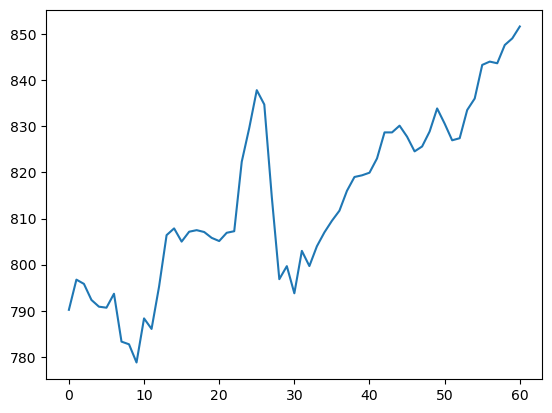

In [49]:
data = df['Open'].values

plt.plot(data)

scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data.reshape(-1,1))
data_scaled

In [50]:
train_size = int(len(data_scaled) * 0.8)
print(train_size)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size-30:]

48


In [51]:
def createDataset(dataset):
    X = []
    y = []

    for i in range (30, len(dataset)):
        X.append(dataset[i-30:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = createDataset(train_data)
X_test, y_test = createDataset(test_data)

In [52]:
print(X_train.shape)
print(X_test.shape)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

(18, 30)
(13, 30)


In [54]:
model = Sequential()

model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))  #Dropout = randomly turns OFF some neurons temporarily.Regularization Technique, To avoid overfitting
model.add(SimpleRNN(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.1531 - val_loss: 0.3124
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.4422 - val_loss: 0.0085
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.2562 - val_loss: 0.1058
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.2780 - val_loss: 0.0948
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.2706 - val_loss: 0.0194
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.1750 - val_loss: 0.0154
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.1730 - val_loss: 0.0819
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.0894 - val_loss: 0.1949
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.2652 - val_loss: 0.2348
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.2496 - val_loss: 0.1511
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0734 - val_loss: 0.0838
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 0.2422 - val_loss:

In [57]:
y_pred = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


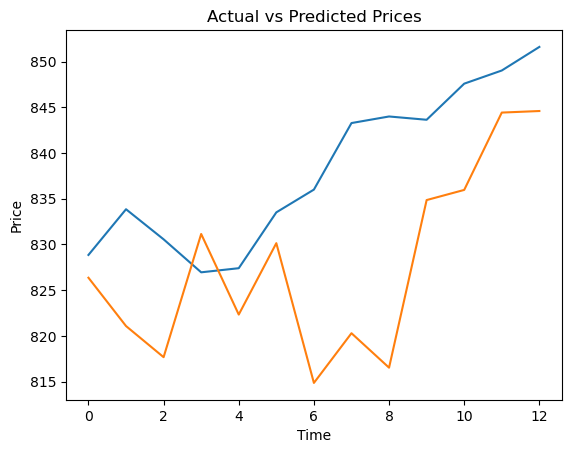

In [58]:
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label='Predicted')

plt.title("Actual vs Predicted Prices")
plt.xlabel('Time')
plt.ylabel('Price')

plt.show()